## Mini Projeto de Análise de Dados

Este é um exercício que resolvi para treinar meus conhecimentos com as bibliotecas Pandas e matplotlib! Este mini projeto simula um cenário real de análise de dados em uma empresa de prestação de serviços, onde trabalhei com as seguintes bases:
- Cadastro de Funcionários
- Cadastro de Clientes
- Serviços Prestados

O que foi analisado?

1️⃣ Cálculo da Folha Salarial Total: Analisei o custo total com salários, incluindo benefícios e impostos, essencial para o planejamento financeiro da empresa.

2️⃣ Faturamento Total: Avaliei o faturamento gerado por cada contrato ao longo de 2019, consolidando as receitas obtidas.

3️⃣ Engajamento dos Funcionários: Descobri que percentual de funcionários estava diretamente envolvido no fechamento de contratos, um dado importante para medir eficiência operacional.

4️⃣ Contratos por Área: Analisei quais áreas da empresa fecharam mais contratos, destacando oportunidades e pontos de melhoria.

5️⃣ Distribuição de Funcionários por Área: Identifiquei a alocação de pessoal, ajudando a otimizar recursos internos.

6️⃣ Ticket Médio Mensal: Calculei o faturamento médio mensal por cliente, fornecendo insights sobre o valor de cada contrato.

Por que este projeto é relevante?
Além de consolidar meus conhecimentos em análise de dados e manipulação de grandes volumes de informações, ele demonstra como a ciência de dados pode fornecer insights estratégicos e guiar a tomada de decisões empresariais.

Ferramentas utilizadas:

🔧 Python (Pandas)

🔧 Excel para visualizações complementares

Agradeço à @Hashtag Treinamentos pela base teórica e prática que tornou este projeto possível! 🚀

### Importando e editando tabelas

In [2]:
# Importando bibliotecas
import pandas as pd # Biblioteca para manipulação de dados
import matplotlib.pyplot as plt # Biblioteca para criação de gráficos

# Carregando os dados do arquivos em um DataFrame
df_funcionarios = pd.read_csv('CadastroFuncionarios.csv', sep=';', decimal=',')
df_clientes = pd.read_csv('CadastroClientes.csv', sep=';', decimal=',')
df_servicos = pd.read_excel('BaseServiçosPrestados.xlsx')

# Removendo a coluna 'Estado Civil' do DataFrame 'df_funcionarios'
df_funcionarios =df_funcionarios.drop(['Estado Civil'], axis=1)

#Exibindo os dado do DataFrame
display(df_funcionarios)
display(df_clientes)
display(df_servicos)


,ID Funcionário,Nome Completo,Salario Base,Impostos,Beneficios,VT,VR,Cargo,Area
0,1,Gabriel Mesquita,21910,10955.0,4382.0,242,719.04,Diretor,Operações
1,2,João Haddad,5404,2702.0,1080.8,154,574.56,Estagiário,Logística
2,3,Amanda Marques Ribeiro,16066,8033.0,3213.2,154,729.12,Estagiário,Administrativo
3,4,Guilherme Nunez,21305,10652.5,4261.0,220,524.16,Analista,Administrativo
4,5,Adelino Gomes,5098,2549.0,1019.6,176,725.76,Analista,Administrativo
...,...,...,...,...,...,...,...,...,...
109,143,Renan Scharnhorst Ott,10793,5396.5,2158.6,242,514.08,Analista,Logística
110,144,Lucas Brum Pereira,4048,2024.0,809.6,198,796.32,Estagiário,Comercial
111,148,Caio Stellet,24596,12298.0,4919.2,242,561.12,Analista,Administrativo
112,149,Fernanda Rocha,5078,2539.0,1015.6,308,665.28,Estagiário,Comercial


,ID Cliente,Cliente,Valor Contrato Mensal
0,1,Teixeira Gonçalves,540
1,2,Souza Santos,1260
2,3,Emídio Alves,3195
3,4,Santos Costa,2520
4,5,Do Monteiro,3510
...,...,...,...
315,316,Manoel Costa,3690
316,317,Gomes Machado,2385
317,318,Alkindar Cardozo,3510
318,319,Pereira Fazenda,4185


,Codigo do Servico,ID Funcionário,ID Cliente,Tempo Total de Contrato (Meses)
0,OS0001,67,1,14
1,OS0002,17,2,12
2,OS0003,116,4,14
3,OS0004,37,5,8
4,OS0005,130,6,8
...,...,...,...,...
232,OS0233,111,315,4
233,OS0234,124,316,8
234,OS0235,72,317,6
235,OS0236,90,319,14


### Análise da Folha Salarial

In [3]:
# Criando uma nova coluna chamada 'Salario Total' no DataFrame 'df_funcionarios'
# O valor de cada linha dessa coluna é calculado somando as seguintes colunas:
# - 'Salario Base'
# - 'Impostos'
# - 'Beneficios'
# - 'VT'
# - 'VR'

df_funcionarios['Salario Total'] = (df_funcionarios['Salario Base'] 
                                    + df_funcionarios['Impostos'] 
                                    + df_funcionarios['Beneficios'] 
                                    + df_funcionarios['VT'] 
                                    + df_funcionarios['VR'])

# Calculando e exibindo o gasto da folha salrial da empresa formatado
print(f'Total gasto com a folha salarial: R${sum(df_funcionarios['Salario Total']):,.2f}')

Total gasto com a folha salarial: R$2,717,493.22


### Análise do Faturamento da Empresa

In [4]:
# Combinando os dados de 'df_servicos' e 'df_clientes' usando 'ID Cliente' como chave
df_fat_empresa = df_servicos[['ID Cliente', 'Tempo Total de Contrato (Meses)']].merge(df_clientes[['ID Cliente', 'Valor Contrato Mensal']])

# Selecionando as colunas necessárias para calcular o faturamento total
df_fat_empresa ['Faturamento_Total'] = df_fat_empresa['Tempo Total de Contrato (Meses)'] * df_fat_empresa['Valor Contrato Mensal']

# Calculando e exibindo o faturamento total da empresa formatado
print(f'Faturamento total da empresa: R${sum(df_fat_empresa['Faturamento_Total']):,.2f}')

Faturamento total da empresa: R$5,519,160.00


### Percentual de Funcionários Envolvidos em Contratos

In [5]:
# Contando a quantidade de funcionários que fecharam contratos
qtd_funcionarios_fecharam = len(df_servicos['ID Funcionário'].unique())
# Contando o total de funcionários cadastrados
qtd_funcionarios_total = len(df_funcionarios['ID Funcionário'])

# Calculando e exibindo o percentual de funcionários que fecharam contratos
print(f'Percentual de funcionários que fecharam contratos: {(qtd_funcionarios_fecharam/qtd_funcionarios_total):.2%}')

Percentual de funcionários que fecharam contratos: 86.84%


### Contratos Fechados por Área

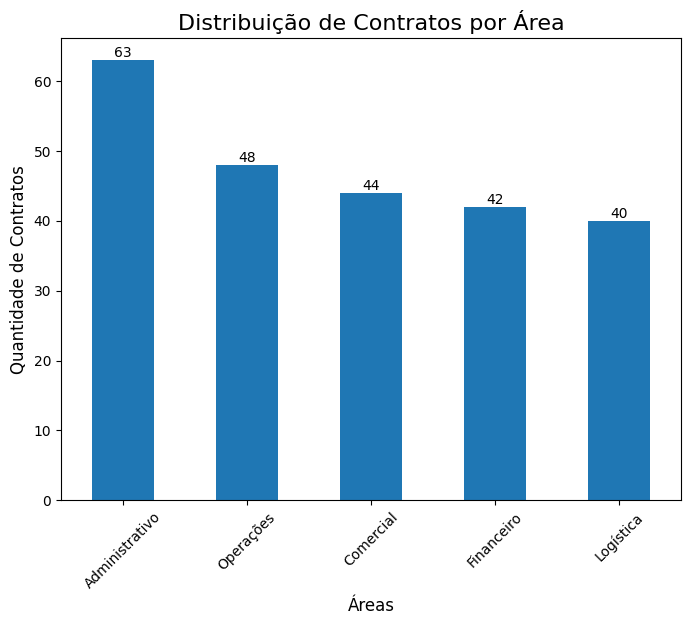

In [9]:
# Combinando dados de funcionários e serviços para associar contratos às áreas
df_contratos_area = df_servicos[['ID Funcionário']].merge(df_funcionarios[['ID Funcionário', 'Area']])
# Contando a quantidade de contratos por área
qtd_contratos_area = df_contratos_area['Area'].value_counts()

# Criando um gráfico de barras para visualizar a distribuição de contratos por área
ax_areas = qtd_contratos_area.plot(kind='bar', x= df_contratos_area['Area'], 
                                  y= qtd_contratos_area, legend=False, figsize=(8, 6))

# Ajustando o título e os rótulos dos eixos do gráfico
ax_areas.set_title('Distribuição de Contratos por Área', fontsize=16)
ax_areas.set_xlabel('Áreas', fontsize=12)
ax_areas.set_ylabel('Quantidade de Contratos', fontsize=12)

# Adicionando anotações com os valores exatos no topo de cada barra
for p in ax_areas.patches:
    ax_areas.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')


# Rotacionando os rótulos do eixo X para melhor legibilidade
plt.xticks(rotation=45)
# Exibindo o gráfico
plt.show()

### Distribuição de Funcionários por Área

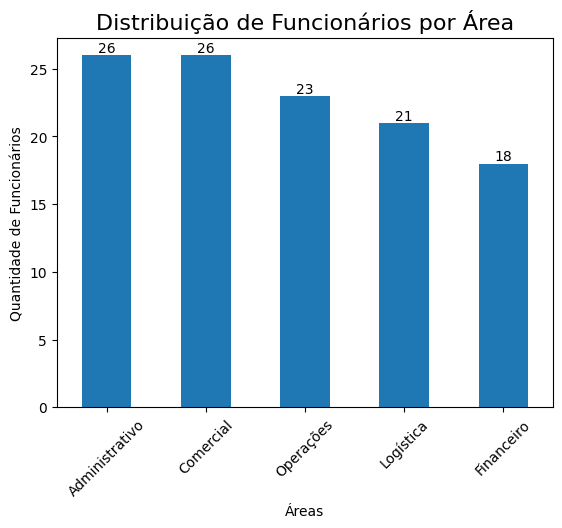

In [10]:
# Contando a quantidade de funcionários em cada área
qtd_funcionarios_area = df_funcionarios['Area'].value_counts()

# Criando um gráfico de barras para visualizar a distribuição de funcionários por área
ax_func_areas = qtd_funcionarios_area.plot(kind="bar", x=df_funcionarios['Area'])

# Ajustando o título e os rótulos dos eixos do gráfico
ax_func_areas.set_title('Distribuição de Funcionários por Área', fontsize=16)
ax_func_areas.set_xlabel('Áreas')
ax_func_areas.set_ylabel('Quantidade de Funcionários')

# Adicionando anotações com os valores exatos no topo de cada barra
for p in ax_func_areas.patches:
    ax_func_areas.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')

# Rotacionando os rótulos do eixo X para melhor legibilidade    
plt.xticks(rotation=45)
# Exibindo o gráfico
plt.show()

### Média do Ticket Mensal

In [8]:
# Calculando a média do valor do contrato mensal dos clientes
ticket_medio = df_clientes['Valor Contrato Mensal'].mean()
# Exibindo a média do ticket mensal da empresa formatada
print(f'Média do ticket mensal da empresa: R${ticket_medio:,.2f}')

Média do ticket mensal da empresa: R$2,502.56
